# LIKWID policy-* summary

Run this notebook from a policy folder such as `performance/` or `ondemand/`.
It auto-detects subfolders like `<policy>-*` and computes:
- Total runtime [s]
- Average total power [W]
- Total energy [J]
- EDP [J*s]

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Settings
base_dir = Path('.')  # run from policy folder (e.g., performance/, ondemand/)
policy_name = base_dir.resolve().name
subfolder_pattern = f'{policy_name}-*'
benchmark_name = None  # None => process all detected benchmarks; set to a name to filter
skip_initial = 3
output_dir = base_dir  # per-benchmark CSV files are written here


In [2]:
import sys
from pathlib import Path

repo_root = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / 'tests' / 'common' / 'process_profiles_lib.py').is_file():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError('Could not locate tests/common/process_profiles_lib.py from current notebook path')

lib_dir = repo_root / 'tests' / 'common'
if str(lib_dir) not in sys.path:
    sys.path.insert(0, str(lib_dir))

from process_profiles_lib import (
    SUM_FIELDS,
    build_policy_summary,
    extract_job_id,
    find_stdout_for_job,
    list_profiles,
    load_likwid_profile,
    newest_profile_for_benchmark,
    plot_benchmark_boxplots,
    plot_likwid_timeseries,
    print_policy_context,
    run_has_fatal_error,
    summarize_profile,
)


In [3]:
per_benchmark_summary, all_output = build_policy_summary(
    base_dir=base_dir,
    subfolder_pattern=subfolder_pattern,
    benchmark_name=benchmark_name,
    skip_initial=skip_initial,
    output_dir=output_dir,
    policy_name=policy_name,
)

print_policy_context(policy_name, subfolder_pattern, benchmark_name)
all_output


Removed 16 extreme-high LIKWID samples using automatic power filtering
Removed 10 extreme-high LIKWID samples using automatic power filtering
Removed 9 extreme-high LIKWID samples using automatic power filtering
Removed 6 extreme-high LIKWID samples using automatic power filtering
Removed 24 extreme-high LIKWID samples using automatic power filtering
Removed 12 extreme-high LIKWID samples using automatic power filtering
Removed 18 extreme-high LIKWID samples using automatic power filtering
Removed 24 extreme-high LIKWID samples using automatic power filtering
Removed 18 extreme-high LIKWID samples using automatic power filtering
Removed 17 extreme-high LIKWID samples using automatic power filtering
Removed 10 extreme-high LIKWID samples using automatic power filtering
Removed 10 extreme-high LIKWID samples using automatic power filtering
Removed 6 extreme-high LIKWID samples using automatic power filtering
Removed 25 extreme-high LIKWID samples using automatic power filtering
Removed 1

,subfolder,benchmark,Total runtime [s],Average total power [W],Total energy [J],EDP [J*s]
0,Average,clvleaf,2460.18,471.77,1160049.66,2.853959e+09
1,performance-0,clvleaf,2454.64,473.03,1160551.00,2.848741e+09
2,performance-1,clvleaf,2458.56,468.61,1151505.53,2.831051e+09
3,performance-2,clvleaf,2460.56,473.12,1163536.55,2.862950e+09
4,performance-3,clvleaf,2458.05,468.70,1151487.42,2.830418e+09
5,performance-4,clvleaf,2469.07,475.37,1173167.78,2.896637e+09
6,Average,hpgmgfv,1297.63,548.01,710468.46,9.219610e+08
7,performance-0,hpgmgfv,1291.19,542.27,699523.66,9.032191e+08
8,performance-1,hpgmgfv,1291.54,548.41,707650.43,9.139609e+08
9,performance-2,hpgmgfv,1302.18,548.30,713322.47,9.288771e+08


Removed 16 extreme-high samples from 'Power L3 [W]' using upper bound 712


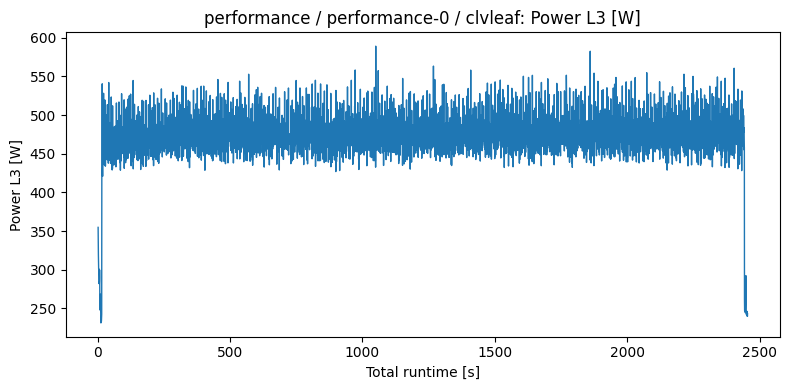

In [4]:
# Plot LIKWID sample time-series for one subfolder/benchmark and one field
selected_subfolder = 'performance-0'
selected_benchmark = None  # None => auto-pick first benchmark found in selected_subfolder
selected_field = 'Power L3 [W]'

plot_likwid_timeseries(
    base_dir=base_dir,
    selected_subfolder=selected_subfolder,
    selected_benchmark=selected_benchmark,
    selected_field=selected_field,
    skip_initial=skip_initial,
    policy_name=policy_name,
    include_benchmark_in_title=True,
)


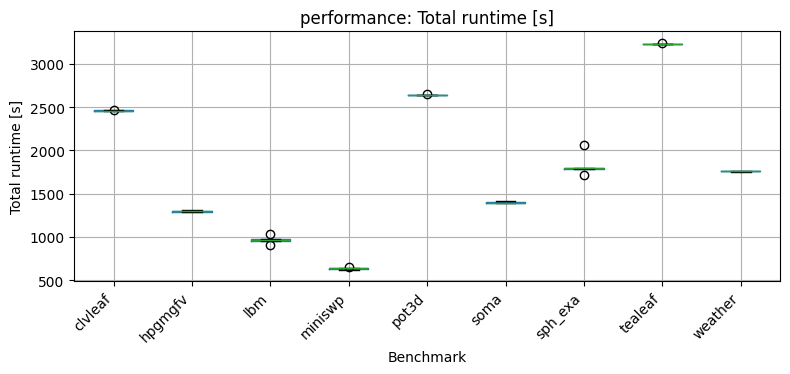

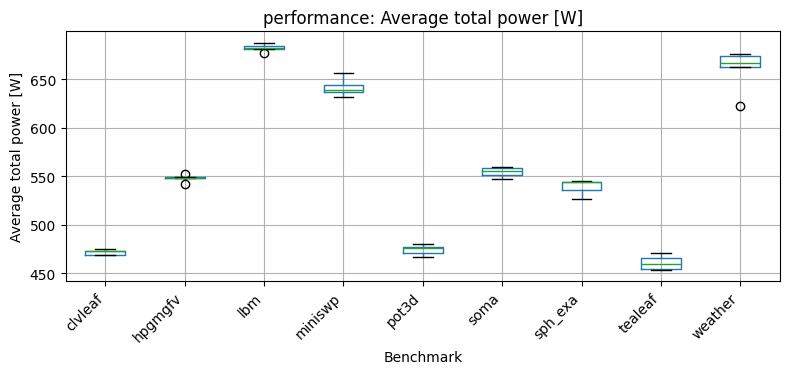

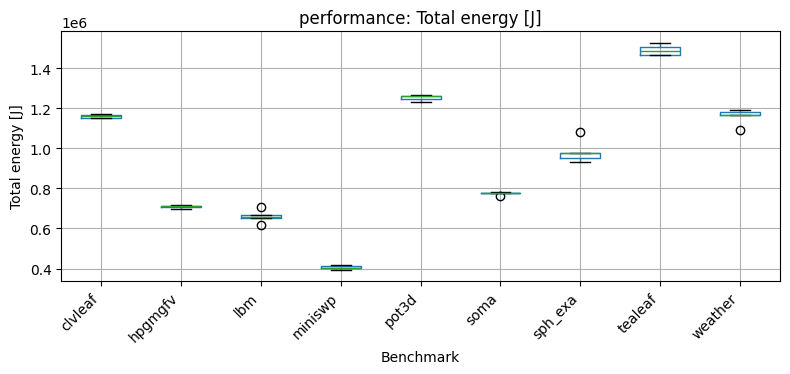

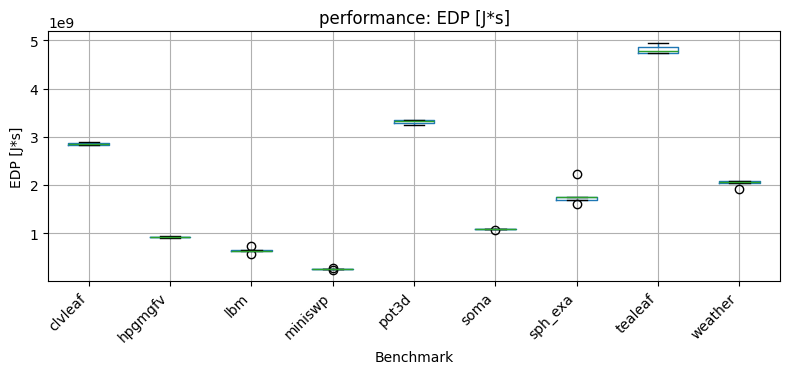

In [5]:
plot_metrics = [
    'Total runtime [s]',
    'Average total power [W]',
    'Total energy [J]',
    'EDP [J*s]',
]

plot_benchmark_boxplots(
    per_benchmark_summary=per_benchmark_summary,
    policy_name=policy_name,
    plot_metrics=plot_metrics,
)
